### Assignment 1 (4 scores):

- Use Numpy only to construct the Logistic Regression model.
- Train that Logistic Regression model dataset using the Gradient Descend approach on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset. *Note that three class in this dataset must be merge into two class as: graduate and non-graduate (dropout or enroll)*.
- Evaluate that Logistic Regression model on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Visualize the loss function of the training process.

In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import Normalizer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [3]:
# fetch dataset
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697)

# data (as pandas dataframes)
X = predict_students_dropout_and_academic_success.data.features
y = predict_students_dropout_and_academic_success.data.targets

continous = ['Previous qualification (grade)', 'Admission grade', 'Unemployment rate', 'Inflation rate', 'GDP']
interger = [col for col in X.columns if col not in continous]
X_norm = X.copy()
y_odd = y.copy()
scaler = Normalizer()
X_norm[continous] = scaler.fit_transform(X[continous])
X_norm[interger] = X[interger]/X[interger].max()
y_odd['Target'] = (y_odd['Target'] == 'Graduate').astype(int)

In [4]:
class LogisticRegression:
    def __init__(self, lr=0.1, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.loss_train = []
        self.accuracy_train = []

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def _loss(self, y, y_predicted):
        return -np.mean(y * np.log(y_predicted) + (1 - y) * np.log(1 - y_predicted))

    def fit(self, X, y, show=True):
        X = np.array(X)
        y = np.array(y).reshape(-1)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.n_iters):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            loss_train_curr = self._loss(y, y_predicted)
            self.loss_train.append(loss_train_curr)

            accuracy_train_curr = self.accuracy(y, y_predicted)
            self.accuracy_train.append(accuracy_train_curr)
            if show:
                if (i+1) % 100 == 0:
                    print(f'Epoch {i + 1}: loss = {loss_train_curr:.4f}  accuracy = {accuracy_train_curr:.4f}')

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X):
        y_predicted = self.predict_proba(X)
        return np.array([1 if i > 0.5 else 0 for i in y_predicted])

    def accuracy(self, y_true, y_pred):
        y_pred_binary = [1 if i > 0.5 else 0 for i in y_pred]
        return np.sum(y_true == y_pred_binary) / len(y_true)

def plot_acc_loss_confusion_matrix(y_true, y_pred, loss_train, accuracy_train, labels=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.plot(loss_train)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss vs Epochs')
    plt.subplot(1, 3, 2)
    plt.plot(accuracy_train)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epochs')
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=labels))


Epoch 100: loss = 0.5764  accuracy = 0.7534
Epoch 200: loss = 0.5313  accuracy = 0.7599
Epoch 300: loss = 0.5073  accuracy = 0.7663
Epoch 400: loss = 0.4919  accuracy = 0.7771
Epoch 500: loss = 0.4807  accuracy = 0.7825
Epoch 600: loss = 0.4720  accuracy = 0.7884
Epoch 700: loss = 0.4650  accuracy = 0.7929
Epoch 800: loss = 0.4591  accuracy = 0.7979
Epoch 900: loss = 0.4540  accuracy = 0.8011
Epoch 1000: loss = 0.4494  accuracy = 0.8033


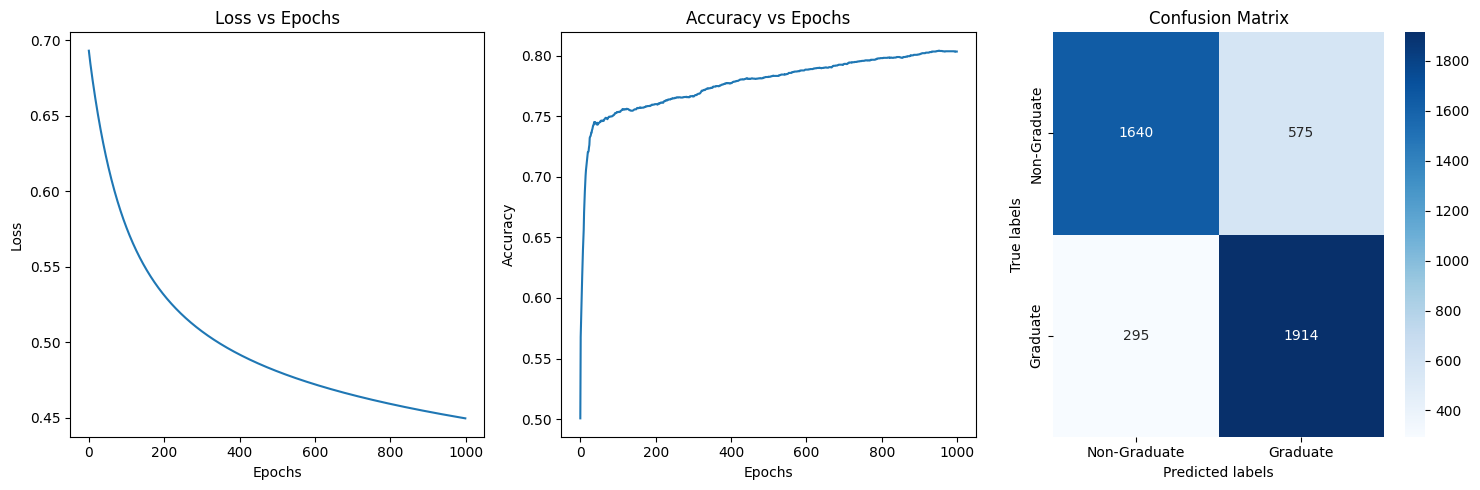


Classification Report:
              precision    recall  f1-score   support

Non-Graduate       0.85      0.74      0.79      2215
    Graduate       0.77      0.87      0.81      2209

    accuracy                           0.80      4424
   macro avg       0.81      0.80      0.80      4424
weighted avg       0.81      0.80      0.80      4424



In [5]:
lgr = LogisticRegression()
lgr.fit(X_norm, y_odd, show=True)
y_pred = lgr.predict(X_norm)
plot_acc_loss_confusion_matrix(y_odd, y_pred, lgr.loss_train, lgr.accuracy_train, labels=['Non-Graduate', 'Graduate'])

### Assignment 2 (4 scores):

- Use Numpy only to construct the Sofmax Regression model.
- Train that Logistic Regression model dataset using the Gradient Descend approach on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Evaluate that Logistic Regression model on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Visualize the loss function of the training process.

In [6]:
class SoftmaxRegression:
    def __init__(self, lr=0.1, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.loss_train = []
        self.accuracy_train = []

    def _softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _loss(self, y, y_predicted):
        return -np.mean(np.sum(y * np.log(y_predicted + 1e-9), axis=1))

    def fit(self, X, y, show=True):
        X = np.array(X)
        y = np.array(y).reshape(-1)
        n_samples, n_features = X.shape
        num_classes = len(np.unique(y))
        y_onehot = np.eye(num_classes)[y]
        self.weights = np.zeros((n_features, num_classes))
        self.bias = np.zeros((1, num_classes))

        for i in range(self.n_iters):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._softmax(linear_model)
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y_onehot))
            db = (1 / n_samples) * np.sum(y_predicted - y_onehot, axis=0, keepdims=True)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            loss_train_curr = self._loss(y_onehot, y_predicted)
            y_true = self.predict(X)
            accuracy_train_curr = self.accuracy(y, y_true)
            self.loss_train.append(loss_train_curr)
            self.accuracy_train.append(accuracy_train_curr)
            if show and (i + 1) % 100 == 0:
                print(f'Epoch {i + 1}: loss = {loss_train_curr:.4f}, accuracy = {accuracy_train_curr:.4f}')

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._softmax(linear_model)

    def predict(self, X):
        y_predicted = self.predict_proba(X)
        return np.argmax(y_predicted, axis=1)

    def accuracy(self, y_true, y_pred):
        return np.sum(y_true == y_pred) / len(y_true)


Epoch 100: loss = 0.8266, accuracy = 0.6892
Epoch 200: loss = 0.7715, accuracy = 0.7016
Epoch 300: loss = 0.7440, accuracy = 0.7061
Epoch 400: loss = 0.7264, accuracy = 0.7109
Epoch 500: loss = 0.7137, accuracy = 0.7127
Epoch 600: loss = 0.7038, accuracy = 0.7154
Epoch 700: loss = 0.6957, accuracy = 0.7197
Epoch 800: loss = 0.6889, accuracy = 0.7213
Epoch 900: loss = 0.6829, accuracy = 0.7238
Epoch 1000: loss = 0.6777, accuracy = 0.7251


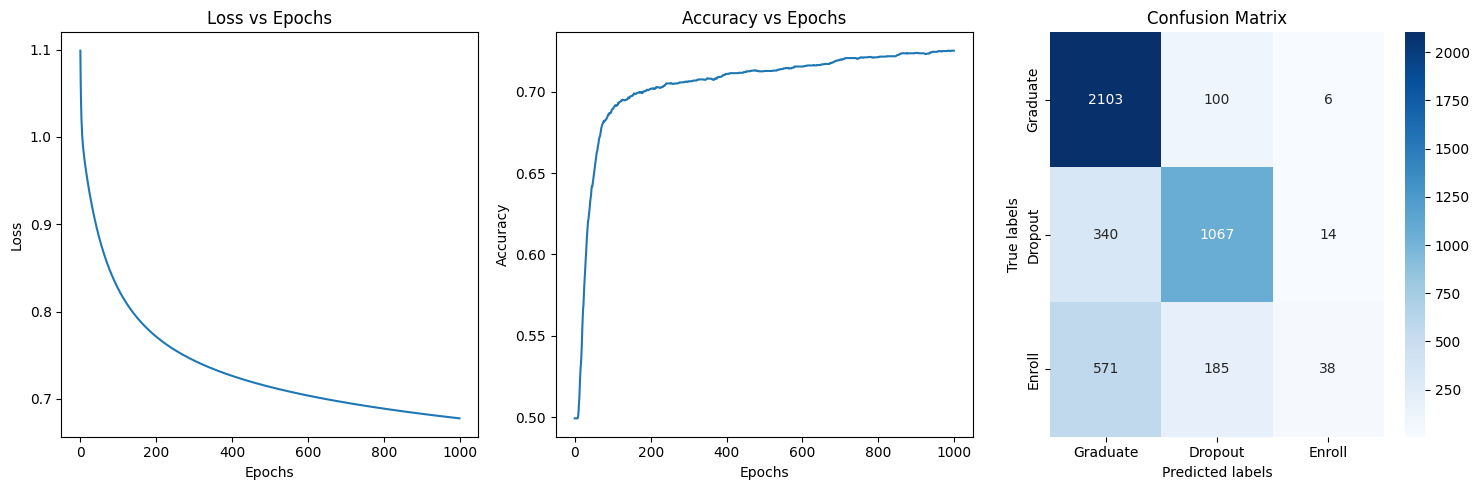


Classification Report:
              precision    recall  f1-score   support

    Graduate       0.70      0.95      0.81      2209
     Dropout       0.79      0.75      0.77      1421
      Enroll       0.66      0.05      0.09       794

    accuracy                           0.73      4424
   macro avg       0.71      0.58      0.55      4424
weighted avg       0.72      0.73      0.67      4424



In [7]:
y_label = y.copy()
y_label['Target'] = y_label['Target'].apply(
    lambda x: 0 if x == 'Graduate' else 1 if x == 'Dropout' else 2
)
sm = SoftmaxRegression()
sm.fit(X_norm, y_label, show=True)
y_pred = sm.predict(X_norm)
plot_acc_loss_confusion_matrix(y_label, y_pred, sm.loss_train, sm.accuracy_train, labels=['Graduate', 'Dropout', 'Enroll'])

### Assignment 3 (2 scores):

- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Logistic Regression on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Softmax Regression on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings("ignore")

def evaluate_and_plot(model, X, y, labels, title):
    y_pred = model.predict(X)

    acc = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, average='weighted')
    recall = recall_score(y, y_pred, average='weighted')
    f1 = f1_score(y, y_pred, average='weighted')

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {title}")
    plt.show()
    print("\nClassification Report:\n", classification_report(y, y_pred))

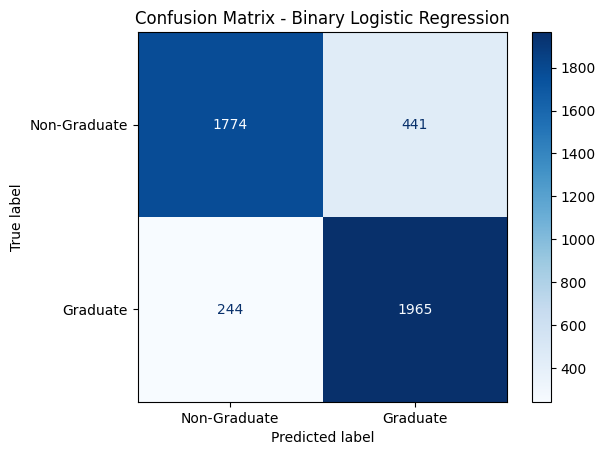


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.80      0.84      2215
           1       0.82      0.89      0.85      2209

    accuracy                           0.85      4424
   macro avg       0.85      0.85      0.84      4424
weighted avg       0.85      0.85      0.84      4424



In [9]:
lgr_binary = LogisticRegression()
lgr_binary.fit(X_norm, y_odd)
evaluate_and_plot(lgr_binary, X_norm, y_odd, ['Non-Graduate', 'Graduate'], "Binary Logistic Regression")

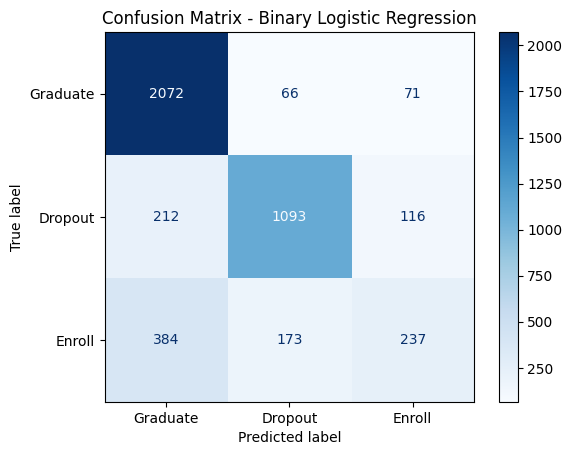


Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.94      0.85      2209
           1       0.82      0.77      0.79      1421
           2       0.56      0.30      0.39       794

    accuracy                           0.77      4424
   macro avg       0.72      0.67      0.68      4424
weighted avg       0.75      0.77      0.75      4424



In [10]:
lgr_softmax = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
lgr_binary.fit(X_norm, y_label)
evaluate_and_plot(lgr_binary, X_norm, y_label, ['Graduate', 'Dropout', 'Enroll'], "Binary Logistic Regression")